In [1]:
"""
Этап 10 (бонус). Адаптированная BCG-матрица.

Что считаем:
- Внутренняя доля SKU относительно лидера.
- Рост выручки между двумя 12-месячными периодами.
- 4 квадранта: Stars, Cash Cows, Question Marks, Dogs.
"""
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))

from scripts.db_config import read_sql, execute_sql, _get_conn_params

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)

REPORTS_DIR = ROOT_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

print("✅ Окружение готово")

✅ Окружение готово


In [2]:
# Period 1: 2009-12 — 2010-11 (12 месяцев)
# Period 2: 2010-12 — 2011-11 (12 месяцев)
bcg = read_sql("""
    SELECT
        stock_code,
        MAX(description) AS description,
        ROUND(SUM(CASE WHEN invoice_date >= '2009-12-01'
                        AND invoice_date < '2010-12-01'
                       THEN revenue ELSE 0 END)::numeric, 2) AS revenue_p1,
        ROUND(SUM(CASE WHEN invoice_date >= '2010-12-01'
                        AND invoice_date < '2011-12-01'
                       THEN revenue ELSE 0 END)::numeric, 2) AS revenue_p2
    FROM sales
    GROUP BY stock_code;
""")

bcg["revenue_p1"] = bcg["revenue_p1"].astype(float)
bcg["revenue_p2"] = bcg["revenue_p2"].astype(float)

# Оставляем только те, у кого продажи были в обоих периодах
bcg = bcg[(bcg["revenue_p1"] > 0) & (bcg["revenue_p2"] > 0)].copy()

print(f"SKU с продажами в обоих периодах: {len(bcg):,}")
print(f"Общая выручка P1: £{bcg['revenue_p1'].sum():,.2f}")
print(f"Общая выручка P2: £{bcg['revenue_p2'].sum():,.2f}")

display(bcg.head())

SKU с продажами в обоих периодах: 3,231
Общая выручка P1: £8,722,681.51
Общая выручка P2: £8,012,019.24


,stock_code,description,revenue_p1,revenue_p2
0,21849,SILVER DIAMANTE PEN IN GIFT BOX,934.58,662.55
3,21976,PACK OF 60 MUSHROOM CAKE CASES,"4,945.57","2,942.73"
4,21874,GIN AND TONIC MUG,"4,079.24","4,218.26"
5,90024B,NEW BAROQUE B'FLY NECKLACE RED,153.46,58.96
6,90180A,BLACK+WHITE NECKLACE W TASSEL,269.40,137.19


In [3]:
# Рост
bcg["growth"] = bcg["revenue_p2"] / bcg["revenue_p1"] - 1

# Относительная внутренняя доля
leader_revenue_p2 = bcg["revenue_p2"].max()
bcg["relative_share"] = bcg["revenue_p2"] / leader_revenue_p2

print(f"Лидер P2: {bcg.loc[bcg['revenue_p2'].idxmax(), 'description']}")
print(f"Выручка лидера P2: £{leader_revenue_p2:,.2f}")

print(f"\nРаспределение роста:")
display(bcg["growth"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(3))

print(f"\nРаспределение внутренней доли:")
display(bcg["relative_share"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(4))

Лидер P2: REGENCY CAKESTAND 3 TIER
Выручка лидера P2: £181,956.85

Распределение роста:


count   3,231.00
mean        0.69
std        18.11
min        -1.00
10%        -0.84
25%        -0.56
50%        -0.23
75%         0.27
90%         1.33
max     1,010.84
Name: growth, dtype: float64


Распределение внутренней доли:


count   3,231.00
mean        0.01
std         0.04
min         0.00
10%         0.00
25%         0.00
50%         0.00
75%         0.01
90%         0.03
max         1.00
Name: relative_share, dtype: float64

In [4]:
# Порог роста: 0% (выше — растущие, ниже — падающие)
growth_threshold = 0.0

# Порог внутренней доли: медиана
share_threshold = bcg["relative_share"].median()

print(f"Порог роста: {growth_threshold:.2%}")
print(f"Порог внутренней доли (медиана): {share_threshold:.4f}")

Порог роста: 0.00%
Порог внутренней доли (медиана): 0.0032


In [5]:
def assign_bcg(row):
    """Присвоить квадрант BCG."""
    high_growth = row["growth"] >= growth_threshold
    high_share = row["relative_share"] >= share_threshold

    if high_growth and high_share:
        return "Stars"
    if not high_growth and high_share:
        return "Cash Cows"
    if high_growth and not high_share:
        return "Question Marks"
    return "Dogs"

bcg["bcg_quadrant"] = bcg.apply(assign_bcg, axis=1)

# Сводка
bcg_summary = (
    bcg.groupby("bcg_quadrant")
    .agg(
        skus=("stock_code", "count"),
        revenue_p1=("revenue_p1", "sum"),
        revenue_p2=("revenue_p2", "sum"),
        avg_growth=("growth", "mean"),
        median_growth=("growth", "median"),
    )
)
bcg_summary["pct_skus"] = bcg_summary["skus"] / len(bcg) * 100
bcg_summary["pct_revenue_p2"] = (
    bcg_summary["revenue_p2"] / bcg_summary["revenue_p2"].sum() * 100
)

print("Сводка по квадрантам BCG:")
display(bcg_summary.round(2))

Сводка по квадрантам BCG:


,skus,revenue_p1,revenue_p2,avg_growth,median_growth,pct_skus,pct_revenue_p2
bcg_quadrant,,,,,,,
Cash Cows,923,"5,147,847.97","3,353,832.23",-0.35,-0.34,28.57,41.86
Dogs,1148,"768,711.55","182,936.47",-0.60,-0.63,35.53,2.28
Question Marks,467,"58,011.40","92,782.08",1.52,0.56,14.45,1.16
Stars,693,"2,748,110.59","4,382,468.46",3.66,0.52,21.45,54.70


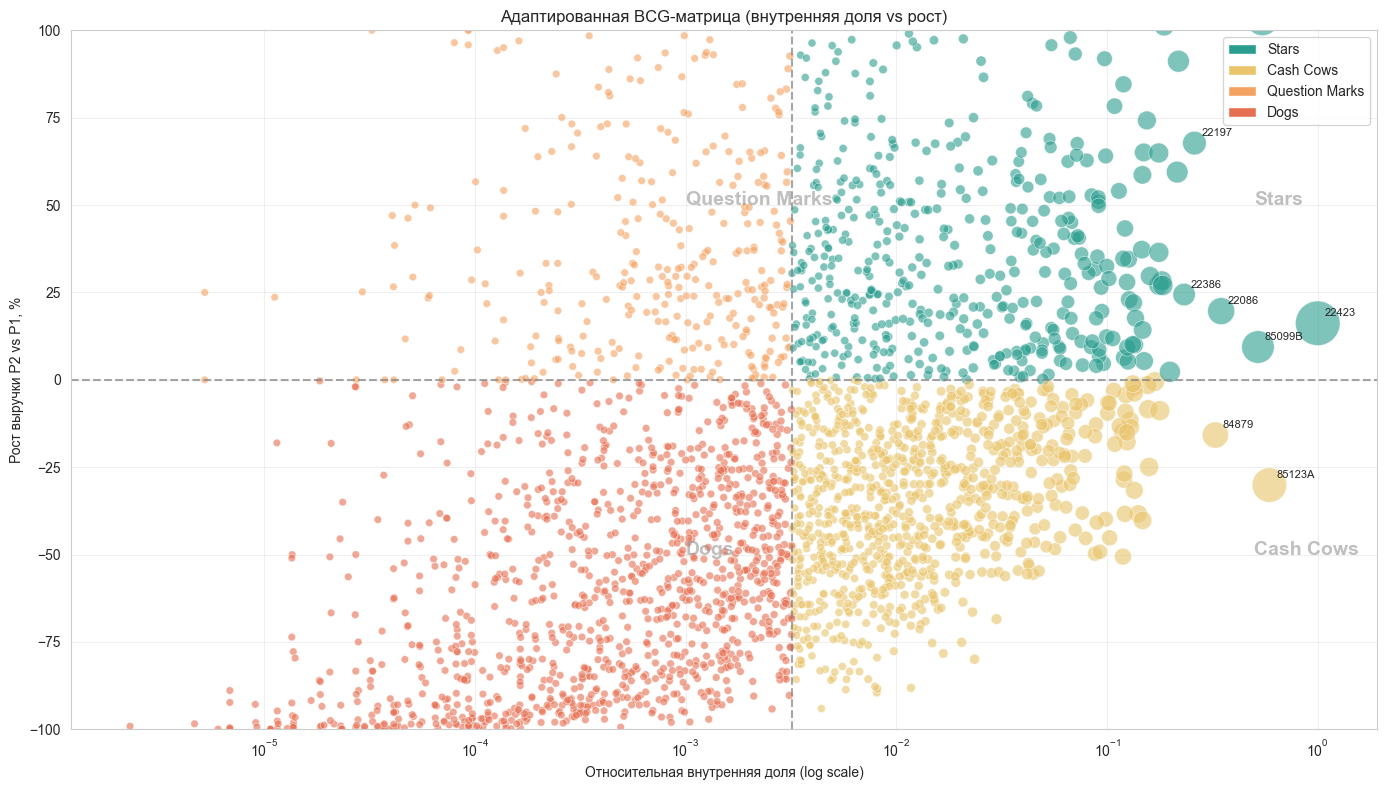

In [7]:
# Размер точки = revenue_p2
point_sizes = bcg["revenue_p2"] / bcg["revenue_p2"].max() * 1000 + 30

fig, ax = plt.subplots(figsize=(14, 8))

# Цвета по квадрантам
colors = {
    "Stars": "#2A9D8F",
    "Cash Cows": "#E9C46A",
    "Question Marks": "#F4A261",
    "Dogs": "#E76F51",
}
colors_arr = bcg["bcg_quadrant"].map(colors)

ax.scatter(
    bcg["relative_share"],
    bcg["growth"] * 100,
    s=point_sizes,
    c=colors_arr,
    alpha=0.6,
    edgecolors="white",
    linewidths=0.5,
)

ax.axvline(share_threshold, linestyle="--", color="grey", alpha=0.7)
ax.axhline(growth_threshold * 100, linestyle="--", color="grey", alpha=0.7)

# Заголовки квадрантов
ax.text(0.001, 50, "Question Marks", fontsize=14, fontweight="bold", color="grey", alpha=0.5)
ax.text(0.5, 50, "Stars", fontsize=14, fontweight="bold", color="grey", alpha=0.5)
ax.text(0.001, -50, "Dogs", fontsize=14, fontweight="bold", color="grey", alpha=0.5)
ax.text(0.5, -50, "Cash Cows", fontsize=14, fontweight="bold", color="grey", alpha=0.5)

# Подписи топ-10 SKU по P2
top10 = bcg.nlargest(10, "revenue_p2")
for _, row in top10.iterrows():
    ax.annotate(
        row["stock_code"],
        (row["relative_share"], row["growth"] * 100),
        xytext=(5, 5), textcoords="offset points", fontsize=8,
    )

ax.set_xscale("log")
ax.set_xlabel("Относительная внутренняя доля (log scale)")
ax.set_ylabel("Рост выручки P2 vs P1, %")
ax.set_title("Адаптированная BCG-матрица (внутренняя доля vs рост)")
ax.set_ylim(-100, 100)
ax.grid(alpha=0.3)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[q], label=q) for q in colors]
ax.legend(handles=legend_elements, loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "bcg_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

In [8]:
bcg_for_db = bcg[[
    "stock_code", "description", "revenue_p1", "revenue_p2",
    "growth", "relative_share", "bcg_quadrant",
]].copy()

execute_sql("DROP TABLE IF EXISTS bcg;")
execute_sql("""
    CREATE TABLE bcg (
        stock_code      text PRIMARY KEY,
        description     text,
        revenue_p1      numeric,
        revenue_p2      numeric,
        growth          numeric,
        relative_share  numeric,
        bcg_quadrant    text
    );
""")

insert_sql = "INSERT INTO bcg VALUES (%s, %s, %s, %s, %s, %s, %s);"
rows = [tuple(r) for r in bcg_for_db.itertuples(index=False, name=None)]

with psycopg2.connect(**_get_conn_params()) as conn:
    with conn.cursor() as cur:
        cur.executemany(insert_sql, rows)
    conn.commit()

print(f"✅ Таблица bcg сохранена ({len(rows):,} строк)")

display(read_sql("""
    SELECT bcg_quadrant, COUNT(*) AS n
    FROM bcg
    GROUP BY bcg_quadrant
    ORDER BY n DESC;
"""))

✅ Таблица bcg сохранена (3,231 строк)


,bcg_quadrant,n
0,Dogs,1148
1,Cash Cows,923
2,Stars,693
3,Question Marks,467


## Этап 10 (бонус). Адаптированная BCG-матрица — ВЫВОДЫ

### Методология

**⚠️ ВАЖНО:** классическая BCG требует данных о рынке и конкурентах.
У нас их нет. Поэтому используем **адаптированную внутреннюю BCG**:

- **Ось X: относительная внутренняя доля** = Revenue P2 SKU / Revenue P2 лидера.
- **Ось Y: рост выручки** = P2 / P1 − 1.

**Периоды (12 месяцев каждый):**
- **P1:** 2009-12-01 — 2010-11-30.
- **P2:** 2010-12-01 — 2011-11-30.

### Ограничение: только устоявшиеся товары

**3 231 SKU из 4 895** имеют продажи **в обоих периодах**.
Остальные **1 664 SKU** исключены:
- Продавались только в P1 → «умерли».
- Продавались только в P2 → «родились недавно».

BCG анализирует **только устоявшийся ассортимент**.

### Итоговая матрица

| Квадрант | SKU | % SKU | Выручка P2 | % выручки P2 | Median growth |
|----------|-----|-------|------------|--------------|---------------|
| **Stars** | 693 | 21.45% | £4 382 468 | **54.70%** | **+52%** |
| **Cash Cows** | 923 | 28.57% | £3 353 832 | 41.86% | **−34%** |
| **Dogs** | 1 148 | 35.53% | £182 936 | 2.28% | **−63%** |
| **Question Marks** | 467 | 14.45% | £92 782 | 1.16% | +56% |
| **Всего** | **3 231** | 100% | £8 012 019 | 100% | — |

### Ключевые выводы

1. **Stars — 21% SKU, 55% выручки.** Ценнейшее ядро.
   Это товары с **высокой долей + положительным ростом**.
   Медианный рост +52%. Примеры: REGENCY CAKESTAND,
   ASSORTED COLOUR BIRD ORNAMENT, PAPER CHAIN KIT.
   **Стратегия:** инвестировать, приоритет в наличии, продвижение.

2. **Cash Cows — 29% SKU, 42% выручки.** Зрелые товары
   с высокой долей, но **отрицательным ростом** (−34% в медиане).
   Примеры: WHITE HANGING HEART (85123A), некоторые топ-ABC.
   **Стратегия:** держать, не инвестировать в рост, поддерживать объём.

3. **Dogs — 36% SKU, 2.3% выручки.** Самая большая группа.
   Средний рост −60%, мизерная выручка.
   **Стратегия:** кандидаты на сокращение. **НО!** — это только
   BCG-взгляд. Пересечение с кандидатами из Этапа 8 (443 SKU)
   даст более точный список.

4. **Question Marks — 14% SKU, 1.2% выручки.** Растущие новички.
   Медианный рост +56%, но доля <0.32% (медиана).
   **Стратегия:** наблюдать, тестировать, инвестировать понемногу.

5. **Общая выручка P2 vs P1: −8.1%.** Типичный SKU потерял **23%**
   выручки. Это значит, что **бизнес немного сократился** между периодами —
   важный контекст для интерпретации.

6. **⚠️ Ограничение: max growth = +1010.84.** Некоторые SKU
   показывают нереальный рост из-за **очень маленькой базы P1**
   (например, £1 → £1 010). **Медиана роста надёжнее среднего.**
   Для честного анализа нужно исключать SKU с малой базой.

### Как читать BCG вместе с ABC/XYZ

- **Stars** часто = **AX/AY** в ABC/XYZ.
- **Cash Cows** ≈ **A-товары с падающим спросом**.
- **Dogs** ≈ **CZ-товары**.
- **Question Marks** ≈ **AZ-новинки**.

**BCG добавляет динамику** — ABC/XYZ показывает текущую картину,
BCG — **тренд**.

### Ограничения BCG
- **Не рыночная доля.** Внутренняя доля ≠ доля рынка.
- **Не рыночный рост.** Рост магазина ≠ рост рынка.
- **Только устоявшиеся товары** (3 231 из 4 895).
- **Малая база искажает рост** — нужны фильтры.
- **Два периода по 12 месяцев** — не учитывает более долгосрочные тренды.

### Графики
- `reports/bcg_matrix.png` — адаптированная BCG-матрица.

### Что дальше
**Этап 11 (бонус):** Basket analysis — что покупают вместе.
**Superset:** дашборд.